In [11]:
import numpy as np
import matplotlib.pyplot as plt

from phase.utils import aia, remove_carrier, subtract_reference

REPO_ROOT = "/Users/rodionsa/Library/CloudStorage/GoogleDrive-sergeyrodionov93@gmail.com/My Drive/work/Projects/HoloEML/holoeml-processing"
DATA_DIR = REPO_ROOT + "/data/"

delta_crop = 400

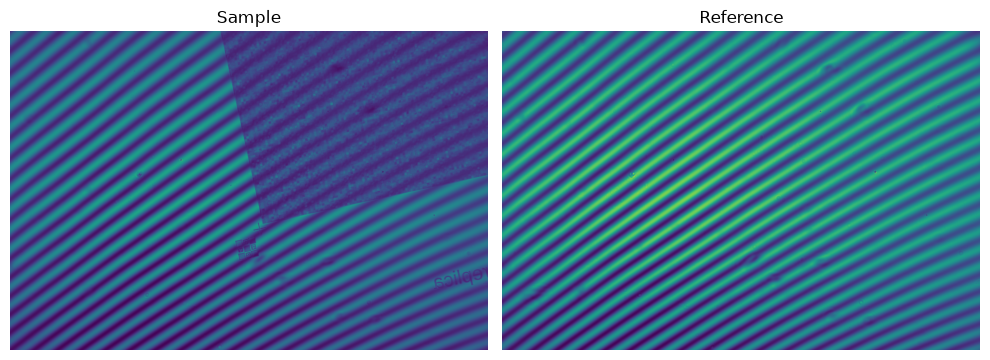

In [12]:
# Read data
data = np.load(DATA_DIR + "piezo_scan_meta_20260721_180617.npz")
images = data['images'][:, delta_crop:3000-delta_crop, delta_crop:4096-delta_crop,0]

data_ref = np.load(DATA_DIR + "piezo_scan_meta_ref_20260721_180831.npz")
images_ref = data_ref['images'][:, delta_crop:3000-delta_crop, delta_crop:4096-delta_crop,0]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title("Sample")
plt.imshow(images[0])
plt.axis('off')

plt.subplot(122)
plt.title("Reference")
plt.imshow(images_ref[0])
plt.axis('off')

plt.tight_layout()

In [13]:
# Extract phases
results = aia(images)
results_ref = aia(images_ref)

a = results.a
b = results.b
phi = results.phi
delta = results.delta

a_ref = results_ref.a
b_ref = results_ref.b
phi_ref = results_ref.phi
delta_ref = results_ref.delta

print(f"Converged: {results.converged}")
print(f"Converged_ref: {results_ref.converged}")
print(f"Kappa_p: {results.kappa_p}")
print(f"Kappa_p_ref: {results_ref.kappa_p}")
print(f"Kappa_ps: {results.kappa_ps}")
print(f"Kappa_ps_ref: {results_ref.kappa_ps}")
print(f"Predicted RMS: {results.predicted_rms}")
print(f"Predicted_ref RMS: {results_ref.predicted_rms}")

Converged: True
Converged_ref: True
Kappa_p: 2.25812953105757
Kappa_p_ref: 2.408570561523216
Kappa_ps: 2.1531325335878173
Kappa_ps_ref: 2.1133241244016268
Predicted RMS: 0.040167420630706524
Predicted_ref RMS: 0.03961322450180899


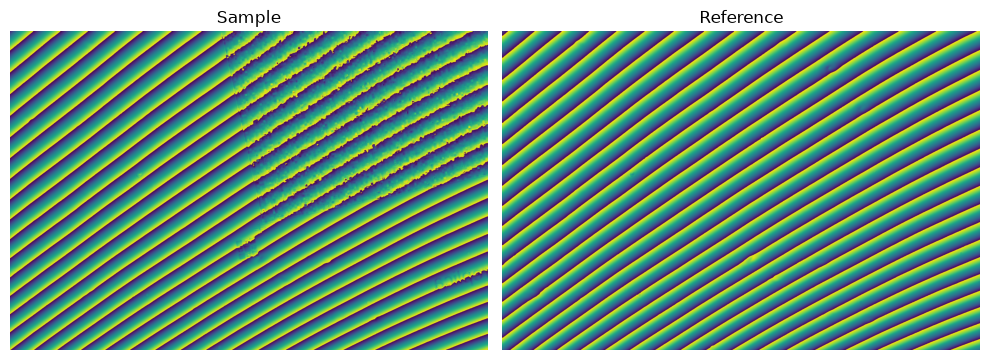

In [14]:
# Plot phi
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title("Sample")
plt.imshow(phi)
plt.axis('off')

plt.subplot(122)
plt.title("Reference")
plt.imshow(phi_ref)
plt.axis('off')

plt.tight_layout()

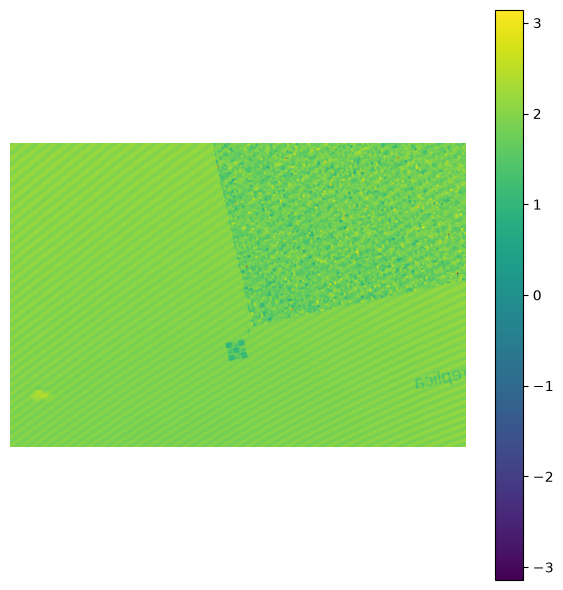

In [15]:
# Phase difference
diff_res =  subtract_reference(phi, phi_ref, b)
phi_diff = diff_res.phi

plt.figure(figsize=(6, 6))
plt.imshow(phi_diff)
plt.axis('off')
plt.colorbar()

plt.tight_layout()

In [27]:
# Remove phase carrier
carrier_results = remove_carrier(phi_ref, b, defocus=False, refine_iters=10, n_blocks=10)
phi_clean = carrier_results.phi

print(f"kx/2pi: {carrier_results.fx}")
print(f"ky/2pi: {carrier_results.fy}")
print(f"kxx: {carrier_results.kxx}")
print(f"kyy: {carrier_results.kyy}")
print(f"kxy: {carrier_results.kxy}")
print(f"piston: {carrier_results.piston}")

kx/2pi: -0.005108733804560543
ky/2pi: -0.007850880738432726
kxx: 0.0
kyy: 0.0
kxy: 0.0
piston: -2.795576986660899


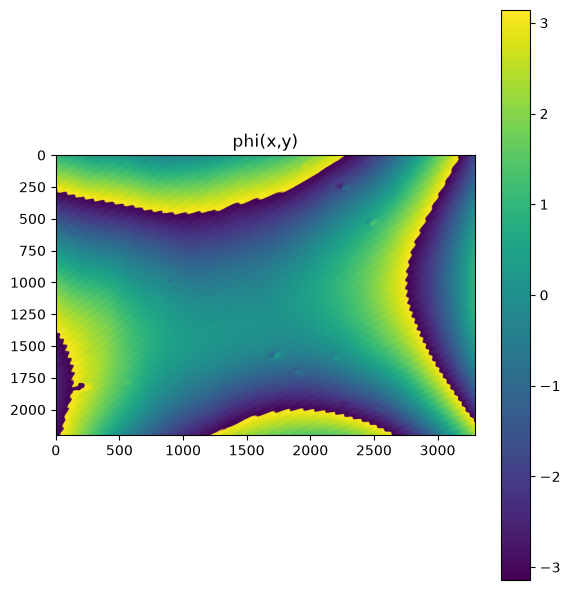

In [28]:
# Plot phi_clean
plt.figure(figsize=(6, 6))

plt.title("phi(x,y)")
plt.imshow(phi_clean)
# plt.xlim([1000, 2000])
# plt.ylim([1100, 1900])
plt.colorbar()

plt.tight_layout()

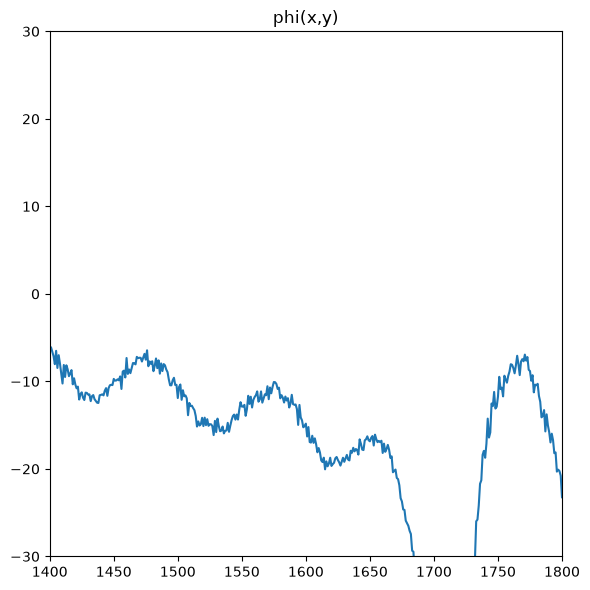

In [31]:
# Plot phi_clean
plt.figure(figsize=(6, 6))

plt.title("phi(x,y)")
plt.plot(phi_clean[1550,:]/np.pi*180)
plt.xlim([1400, 1800])
plt.ylim([-30, 30])
plt.tight_layout()